In [12]:
import sys
sys.path.append('../src')

from credit_risk.data.loader import load_german_credit
from credit_risk.models.baseline import build_baseline_pipeline, evaluate_model, build_lightgbm_pipeline
from credit_risk.features.prepare import split_features_target
from sklearn.model_selection import train_test_split
import shap

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
df = load_german_credit('../data/raw/german_credit.csv')

In [14]:
x, y = split_features_target(df)
X_train, X_test, Y_train, Y_test = train_test_split(
x, y, test_size=0.2, stratify=y, random_state=42
)  # ИЗМЕНЕНО: раньше вызывалось без аргументов — теперь передаём x, y и параметры разбиения

num_cols = X_train.select_dtypes(include='number').columns.tolist()  # ИЗМЕНЕНО: было x.select_dtypes(...) — теперь именно X_train, а не весь x
cat_cols = X_train.select_dtypes(include='object').columns.tolist()  # аналогично

Построй build_lightgbm_pipeline, обучи на train
Создай TreeExplainer — но есть нюанс: SHAP обычно работает после препроцессинга (на данных, которые уже прошли через ColumnTransformer), а не на сырых X. Значит понадобится либо доставать модель из pipeline отдельно (pipeline.named_steps['model']), либо трансформировать X_test через pipeline.named_steps['preprocessor'] перед тем как передавать в SHAP.

In [15]:
pipeline = build_lightgbm_pipeline(num_cols, cat_cols)
pipeline.fit(X_train, Y_train)  # ИЗМЕНЕНО: убрано лишнее присваивание "model =" — fit меняет pipeline на месте

[LightGBM] [Info] Number of positive: 240, number of negative: 560
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001211 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 444
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 56
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.300000 -> initscore=-0.847298
[LightGBM] [Info] Start training from score -0.847298
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [16]:
model = pipeline.named_steps['model']
X_test_transformed = pipeline.named_steps['preprocessor'].transform(X_test)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


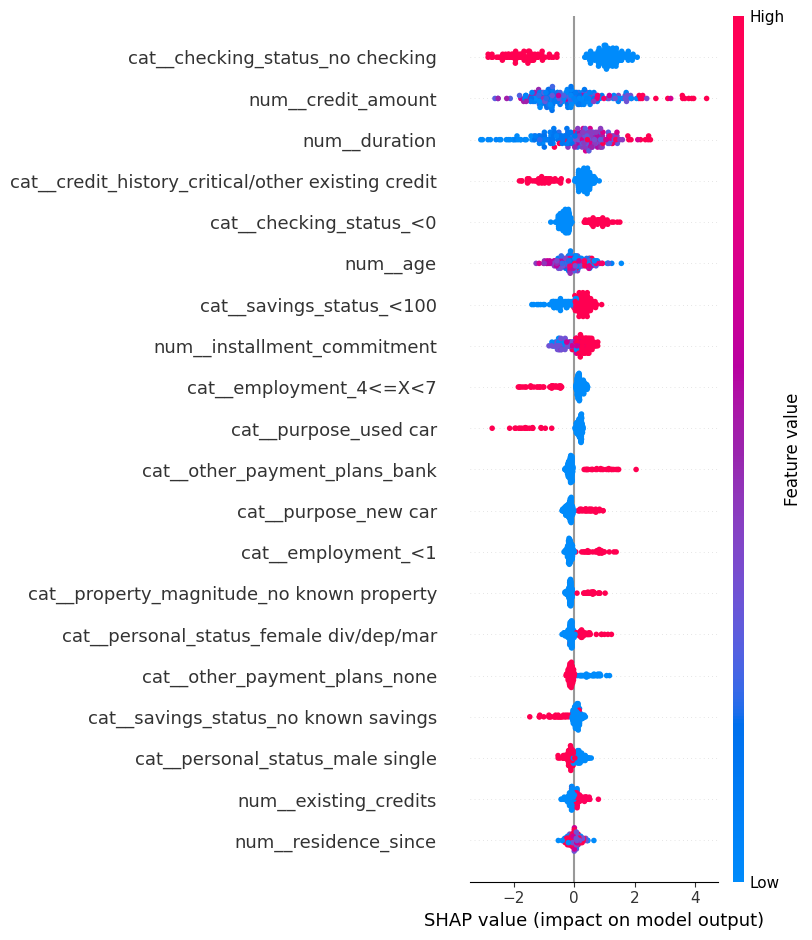

In [18]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_transformed)
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)